# 🤖 Project Budget & Duration Predictor
Predicts **final_budget_usd** and **duration_days** from project features.

Prices are normalized to **USD** (via the daily `usd_rate`) instead of raw IRR,
since IRR has been too unstable over this dataset's ~15-year span to be a
meaningful regression target on its own.

Sections:
1. Load & inspect
2. Target engineering (USD normalization, null handling, log transform)
3. Feature engineering & encoding
4. EDA — distributions, correlations
5. Train models — classical ML (GradientBoosting, Random Forest, XGBoost)
6. Train a deep learning model (feed-forward neural net)
7. Classical vs Deep Learning comparison
8. Feature importance (classical models)
9. SHAP — per-prediction explanations
10. Error analysis
11. Cross-validation
12. Inference helper

In [2]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
ACCENT, ACCENT2 = '#5B8DEF', '#F4845F'

# ── Paths ────────────────────────────────────────────────────────────────
CSV_PATH = Path('../ml_dataset/full_dataset.csv')   # <-- adjust if needed
# CSV_PATH = Path('/absolute/path/to/full_dataset.csv')

BUDGET_RATIO_THRESHOLD = 3.0  # max/min ratio to accept imputed budget (avg of min/max)

# Only rows with a resolvable USD exchange rate can have a USD target.
# (build_dataset.py already computes this from the nearest available
# daily rate, average of open/high/low/close, keyed off scraped_date_created.)
REQUIRE_USD_RATE = True

ENUM_COLS = [
    'project_type', 'ai_level', 'business_logic', 'data_volume',
    'integration_complexity', 'ui_complexity', 'algorithmic_complexity'
]
# Columns that are not model inputs
NON_FEATURE = [
    'project_id','title','category','organization','created_at','scraped_date_created',
    'final_budget','log_final_budget','budget_min','budget_max','log_budget_min','log_budget_max',
    'budget_range','budget_range_ratio','has_final_budget','duration',
    'description','skills','outer_link','updated_at','category_scraped_id','description_length',
     'description_word_count', 'skill_count',
    #   'external_api_count','estimated_screens','estimated_entities',
    #   'requires_refactoring','requires_reverse_engineering','cross_platform',
    # 'ai_level','business_logic','data_volume','integration_complexity','ui_complexity','algorithmic_complexity',
    'feature_score_sum','feature_count','feature_score_mean','feature_score_max'

    # USD normalization columns (rate + amounts) — inputs to target engineering,
    # not model features themselves
    'usd_rate','usd_rate_date','final_budget_usd','log_final_budget_usd',
    'budget_min_usd','budget_max_usd','log_budget_min_usd','log_budget_max_usd',
    'budget_range_usd',
    # derived targets added later
    'target_budget','is_budget_imputed','is_days_null',
    'log_target_budget',
]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_raw = pd.read_csv(CSV_PATH)
print(f'✅  {len(df_raw):,} rows  ·  {df_raw.shape[1]} columns')
print(f'    Organizations: {df_raw.organization.unique()}')

if REQUIRE_USD_RATE and 'usd_rate' in df_raw.columns:
    n_no_rate = df_raw['usd_rate'].isna().sum()
    print(f'    Rows with no usable USD rate (dropped before modeling): '
          f'{n_no_rate:,} ({n_no_rate/len(df_raw):.1%})')

df_raw.head(2)
print(df_raw.columns.tolist())

✅  19,668 rows  ·  164 columns
    Organizations: <StringArray>
['Karlancer', 'Ponisha']
Length: 2, dtype: str
    Rows with no usable USD rate (dropped before modeling): 0 (0.0%)
['project_id', 'title', 'category', 'organization', 'created_at', 'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget', 'log_final_budget', 'final_budget_usd', 'log_final_budget_usd', 'budget_min', 'budget_max', 'log_budget_min', 'log_budget_max', 'budget_min_usd', 'budget_max_usd', 'log_budget_min_usd', 'log_budget_max_usd', 'budget_range_usd', 'budget_range_ratio', 'has_final_budget', 'duration', 'duration_days', 'description_length', 'description_word_count', 'skill_count', 'skills', 'description', 'outer_link', 'Authentication', 'Authorization & Role Management', 'User Management', 'User Profiles', 'Infrastructure & Operations', 'Administration Panel', 'Dashboard', 'Settings & Configuration', 'Content Management', 'Rich Text Editing', 'Media Management', 'Forms & Data Collection', 'File Upl

## 1 · Target engineering
**USD normalization:** every budget figure is converted from IRR to USD using
`usd_rate` (nearest available daily rate) *before* any null-handling. Rows with
no resolvable `usd_rate` are dropped — we can't meaningfully price a project
without knowing what its IRR figure was worth at the time.

**Budget null rule:** if `final_budget_usd` is null and `budget_max_usd / budget_min_usd ≤ threshold` → use average of min/max. Otherwise drop the row.

**Duration null rule:** fill with dataset median, add `is_days_null` flag so the model knows the value was imputed.

Rows dropped (no USD rate): 0
Rows before: 19,668  |  dropped (ratio too high): 6977  |  kept: 12,691
Budget imputed (avg min/max): 1843
Duration filled with median (5 days): 5617



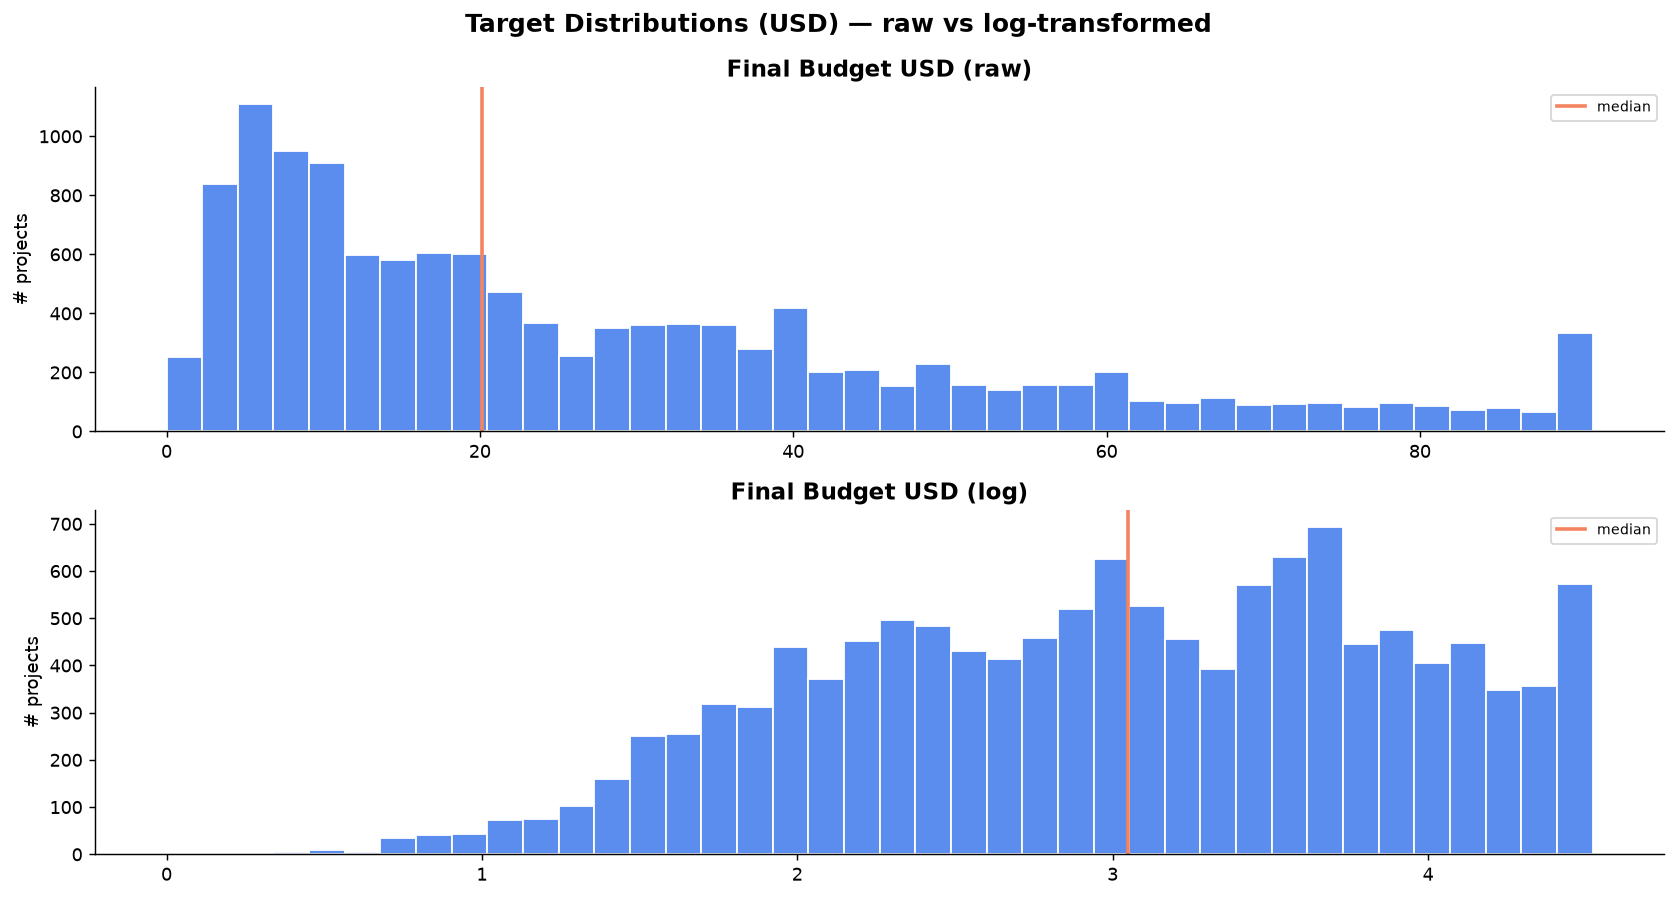

In [3]:
# Drop rows with no usable USD rate first — everything downstream is USD-denominated.
df = df_raw[df_raw['usd_rate'].notna()].copy() if REQUIRE_USD_RATE else df_raw.copy()
n_dropped_no_rate = len(df_raw) - len(df)
PCT_THRESHOLD = 0.10
PRICE_THRESHOLD_UP = 100
PRICE_THRESHOLD_DOWN = 0
# ── Budget (USD) ─────────────────────────────────────────────────────────
def resolve_final_budget(row):
    if row['final_budget_usd'] > PRICE_THRESHOLD_UP or row['final_budget_usd'] < PRICE_THRESHOLD_DOWN :
        return np.nan, False 
    if pd.notna(row['final_budget_usd']) and row["final_budget_usd"] != 0 and not row['final_budget_usd'] < row['budget_min_usd'] * (1 - PCT_THRESHOLD):
        return row['final_budget_usd'], False   # (value, is_imputed)
    ratio = row['budget_max_usd'] / max(row['budget_min_usd'], 1e-6)
    if ratio <= BUDGET_RATIO_THRESHOLD:
        estimated_final_price =  (row['budget_min_usd'] + row['budget_max_usd']) / 2
        if estimated_final_price > PRICE_THRESHOLD_UP or estimated_final_price < PRICE_THRESHOLD_DOWN :
            return np.nan, False 
        return estimated_final_price, True
    # return np.nan, False   # ratio too high → will be dropped

df[['target_budget', 'is_budget_imputed']] = df.apply(
    lambda r: pd.Series(resolve_final_budget(r)), axis=1
)
before = len(df)
df = df[df['target_budget'].notna()].copy()
dropped = before - len(df)

# ── Duration ─────────────────────────────────────────────────────────────
duration_median = df['duration_days'].median()
df['is_days_null'] = df['duration_days'].isna().astype(int)
df['duration_days'] = df['duration_days'].fillna(duration_median)

# ── Log-transform targets (right-skewed money/time values) ────────────────
df['log_target_budget']   = np.log1p(df['target_budget'])

print(f'Rows dropped (no USD rate): {n_dropped_no_rate:,}')
print(f'Rows before: {before:,}  |  dropped (ratio too high): {dropped}  |  kept: {len(df):,}')
print(f'Budget imputed (avg min/max): {df.is_budget_imputed.sum()}')
print(f'Duration filled with median ({duration_median:.0f} days): {df.is_days_null.sum()}')
print()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, col, label in [
    (axes[0], 'target_budget',       'Final Budget USD (raw)'),
    (axes[1], 'log_target_budget',   'Final Budget USD (log)'),
]:
    ax.hist(df[col].clip(upper=df[col].quantile(0.98)), bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(df[col].median(), color=ACCENT2, linewidth=2, label='median')
    ax.set_title(label); ax.set_ylabel('# projects'); ax.legend(fontsize=8)
fig.suptitle('Target Distributions (USD) — raw vs log-transformed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [6]:
import json
import numpy as np
import pandas as pd

# ============================================================
# Load confidence feature names from taxonomy
# ============================================================

with open("taxonomy/taxonomy.json", "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

CONFIDENCE_FEATURES = [
    c for c in list(taxonomy["features"]["values"])
    if c in df_raw.columns
]

print(df_raw.columns)

print(f"Found {len(CONFIDENCE_FEATURES)} confidence features.")

# ============================================================
# Confidence preprocessing
# ============================================================

# Available modes:
#
# A      -> Keep original (0,1,2,3,4,5)
# B      -> Remove weak detections (1,2 -> 0)
# C      -> Binary presence (3,4,5 -> 1)
# MAP    -> Manual nonlinear mapping
# POWER  -> (confidence / 5)^2

CONFIDENCE_MAP = {
    0: 0.00,
    1: 0.02,
    2: 0.08,
    3: 0.35,
    4: 0.75,
    5: 1.00,
}


def transform_confidence(df, mode="A"):
    """
    Transform only taxonomy confidence features.

    Parameters
    ----------
    df : pandas.DataFrame

    mode : str
        "A"      -> original
        "B"      -> 1,2 become 0
        "C"      -> binary (>=3 -> 1)
        "MAP"    -> manual nonlinear mapping
        "POWER"  -> (x/5)^2

    Returns
    -------
    pandas.DataFrame
    """

    df = df.copy()

    mode = mode.upper()

    if mode == "A":
        pass

    elif mode == "B":

        df[CONFIDENCE_FEATURES] = df[CONFIDENCE_FEATURES].replace({
            1: 0,
            2: 0,
        })

    elif mode == "C":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES] >= 3
        ).astype(np.int8)

    elif mode == "MAP":

        df[CONFIDENCE_FEATURES] = (
            df[CONFIDENCE_FEATURES]
            .replace(CONFIDENCE_MAP)
            .astype(np.float32)
        )

    elif mode == "POWER":

        df[CONFIDENCE_FEATURES] = (
            (df[CONFIDENCE_FEATURES] / 5.0) ** 2
        ).astype(np.float32)

    else:
        raise ValueError(f"Unknown mode '{mode}'")

    return df

Index(['project_id', 'title', 'category', 'organization', 'created_at',
       'scraped_date_created', 'usd_rate', 'usd_rate_date', 'final_budget',
       'log_final_budget',
       ...
       'data_volume', 'integration_complexity', 'ui_complexity',
       'algorithmic_complexity', 'updated_at', 'category_scraped_id',
       'feature_score_sum', 'feature_count', 'feature_score_mean',
       'feature_score_max'],
      dtype='str', length=164)
Found 82 confidence features.


In [8]:
import sys
import torch

print("Python:", sys.executable)
print("Torch :", torch.__file__)
print("Version:", torch.__version__)

Python: d:\PROGRAMMING\Web\Final Project\KarChandV2\backend\venv\Scripts\python.exe
Torch : d:\PROGRAMMING\Web\Final Project\KarChandV2\backend\venv\Lib\site-packages\torch\__init__.py
Version: 2.11.0+cu128


In [ ]:
lengths = df["description"].fillna("").str.split().str.len()

print(lengths.describe())
print("Max words:", lengths.max())

longest = df.loc[lengths.idxmax(), "description"]
print(longest[:1000])

## Embedding

In [6]:
import time
from sentence_transformers import SentenceTransformer

t0 = time.time()
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda",
)
print("Loaded in", time.time() - t0)

t0 = time.time()
emb = model.encode(
    ["سلام دنیا"],
    convert_to_numpy=True,
    show_progress_bar=False,
)
print("Encoded in", time.time() - t0)

print(emb.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2658.55it/s]


Loaded in 143.2265968322754
Encoded in 3.0844292640686035
(1, 384)


In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

# ==========================================================
# Parameters
# ==========================================================

EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"      # multilingual
PCA_COMPONENTS = 64
BATCH_SIZE = 4

# ==========================================================
# Load embedding model
# ==========================================================

model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

print(model.device)

# ==========================================================
# Encode descriptions
# ==========================================================

texts = (
    df["description"]
    .fillna("")
    .astype(str)
    .tolist()
)

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Original embedding shape:", embeddings.shape)

# ==========================================================
# PCA
# ==========================================================

pca = PCA(
    n_components=PCA_COMPONENTS,
    random_state=42,
)

embeddings_pca = pca.fit_transform(embeddings)

print("Reduced shape:", embeddings_pca.shape)

print(
    f"Explained variance: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

# ==========================================================
# Add to dataframe
# ==========================================================

emb_cols = [
    f"emb_{i}"
    for i in range(PCA_COMPONENTS)
]

emb_df = pd.DataFrame(
    embeddings_pca,
    columns=emb_cols,
    index=df.index,
)

df = pd.concat(
    [df, emb_df],
    axis=1,
)

print(df.shape)

KeyboardInterrupt: 

In [9]:
from sklearn.preprocessing import StandardScaler

emb_cols = [f"emb_{i}" for i in range(PCA_COMPONENTS)]

emb_scaler = StandardScaler()

df[emb_cols] = emb_scaler.fit_transform(df[emb_cols])

## 2 · Feature engineering & encoding

In [10]:


# ============================================================
# Ordered categorical columns
# ============================================================

PROJECT_TYPE_COL = "project_type"

ORDINAL_COLS = [
    "ai_level",
    "business_logic",
    "data_volume",
    "integration_complexity",
    "ui_complexity",
    "algorithmic_complexity",
]

ENUM_ORDER = {
    "ai_level": ["none", "basic", "advanced"],
    "business_logic": ["low", "medium", "high"],
    "data_volume": ["small", "medium", "large"],
    "integration_complexity": ["low", "medium", "high"],
    "ui_complexity": ["low", "medium", "high"],
    "algorithmic_complexity": ["low", "medium", "high"],
}

# ============================================================
# Keep only columns that exist and are used as features
# ============================================================

ordinal_cols_present = [
    c for c in ORDINAL_COLS
    if c in df.columns and c not in NON_FEATURE
]

project_type_present = (
    [PROJECT_TYPE_COL]
    if PROJECT_TYPE_COL in df.columns and PROJECT_TYPE_COL not in NON_FEATURE
    else []
)

cols_to_clean = ordinal_cols_present + project_type_present

# ============================================================
# Normalize string values
# ============================================================

if cols_to_clean:
    df[cols_to_clean] = (
        df[cols_to_clean]
        .astype(str)
        .apply(lambda s: s.str.strip().str.lower())
    )

# ============================================================
# Show values before encoding
# ============================================================

print("=== Enum values before encoding ===")

for col in cols_to_clean:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(20))

# ============================================================
# Ordinal encode ordered columns
# ============================================================

if ordinal_cols_present:

    enc = OrdinalEncoder(
        categories=[ENUM_ORDER[c] for c in ordinal_cols_present],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    df[ordinal_cols_present] = enc.fit_transform(
        df[ordinal_cols_present]
    )

# ============================================================
# One-hot encode project_type
# ============================================================

if project_type_present:

    df = pd.get_dummies(
        df,
        columns=project_type_present,
        prefix="project_type",
        dtype=np.int8,
    )

# ============================================================
# Build feature list
# ============================================================

ALL_FEATURES = [
    c
    for c in df.columns
    if c not in NON_FEATURE and df[c].dtype != object
]

print(f"\nNumber of features: {len(ALL_FEATURES)}")

# ============================================================
# Prepare train/test
# ============================================================
MODE="A"
df_model = transform_confidence(df, MODE)

X = df_model[ALL_FEATURES]
yB = df_model["log_target_budget"]

X_tr, X_te, yB_tr, yB_te = train_test_split(
    X,
    yB,
    test_size=0.30,
    random_state=42,
)

print("\n-------------------")
print(X_tr.head(2))

print("\n=========")
print(yB_tr.head(2))

print(X_tr.columns.tolist())
print(yB_tr.name)

=== Enum values before encoding ===

ai_level
ai_level
-1.0    12691
Name: count, dtype: int64

business_logic
business_logic
-1.0    12691
Name: count, dtype: int64

data_volume
data_volume
-1.0    12691
Name: count, dtype: int64

integration_complexity
integration_complexity
-1.0    12691
Name: count, dtype: int64

ui_complexity
ui_complexity
-1.0    12691
Name: count, dtype: int64

algorithmic_complexity
algorithmic_complexity
-1.0    12691
Name: count, dtype: int64

Number of features: 136

-------------------
       usd_rate  duration_days  Authentication  \
19381  55651.25            5.0               0   
13400  24511.75            5.0               0   

       Authorization & Role Management  User Management  User Profiles  \
19381                                0                0              1   
13400                                0                0              0   

       Infrastructure & Operations  Administration Panel  Dashboard  \
19381                            0 

In [13]:
print(df.shape)

(12691, 238)


## 3 · EDA — target vs key features

In [14]:
# Budget by category (top 15 by median)
cat_budget = (df.groupby('project_type')['target_budget']
                .median().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10, 5))
cat_budget.plot(kind='barh', ax=ax, color=ACCENT)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Median Final Budget (USD) by Category (top 15)')
ax.set_xlabel('Median budget (USD)')
plt.tight_layout(); plt.show()

# Budget vs complexity enums
raw_enum_cols = ['business_logic','ui_complexity','algorithmic_complexity','integration_complexity','ai_level','project_type']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), raw_enum_cols):
    order = ENUM_ORDER.get(col, sorted(df_raw[col].dropna().unique()))
    present = [v for v in order if v in df_raw[col].values]
    data = [df.loc[df_raw.loc[df.index, col] == v, 'target_budget'].clip(upper=df['target_budget'].quantile(0.95))
            for v in present]
    ax.boxplot(data, tick_labels=present, patch_artist=True,
               boxprops=dict(facecolor=ACCENT+'55', color=ACCENT),
               medianprops=dict(color=ACCENT2, linewidth=2))
    ax.set_title(col.replace('_',' ').title())
    ax.set_ylabel('Budget (clipped p95)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Budget Distribution by Enum Modifiers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()




KeyError: 'project_type'

## Weights

In [72]:
print(X_tr.isna().sum().sort_values(ascending=False))

usd_rate                           0
duration_days                      0
Authentication                     0
Authorization & Role Management    0
User Management                    0
                                  ..
requires_refactoring               0
requires_reverse_engineering       0
cross_platform                     0
project_type                       0
feature_score_max                  0
Length: 121, dtype: int64


In [9]:
import numpy as np

def interval_accuracy(y_true_log, y_pred_log, pct=0.20):
    """
    Percentage of predictions within ±pct of the true price.
    Inputs are log1p(price).
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rel_error = np.abs(y_pred - y_true) / np.maximum(y_true, 1)

    return np.mean(rel_error <= pct)

## 4 · Train models — Budget prediction

In [95]:
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

# ============================================================
# Train + Evaluate CatBoost
# ============================================================

def evaluate_catboost(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name,
    weight_mode="sqrt",   # none | log | sqrt | linear
):

    # --------------------------------------------------------
    # Sample weights
    # --------------------------------------------------------

    budget_train = np.expm1(y_tr)

    if weight_mode == "none":
        sample_weight = None

    elif weight_mode == "log":
        sample_weight = np.log1p(budget_train)

    elif weight_mode == "sqrt":
        sample_weight = np.sqrt(budget_train + 1)

    elif weight_mode == "linear":
        sample_weight = budget_train

    else:
        raise ValueError("Unknown weight mode")

    if sample_weight is not None:
        sample_weight = sample_weight / sample_weight.mean()

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = CatBoostRegressor(

        iterations=5000,
        learning_rate=0.02,
        depth=6,

        l2_leaf_reg=10,

        bootstrap_type="Bayesian",
        bagging_temperature=1,

        loss_function="RMSE",
        eval_metric="RMSE",

        random_seed=42,

        early_stopping_rounds=200,

        verbose=100,
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_tr,
        y_tr,

        sample_weight=sample_weight,

        eval_set=(X_te, y_te),

        use_best_model=True,

    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae_te = mean_absolute_error(
        np.expm1(y_te),
        np.expm1(pred_te),
    )

    rmse_te = np.sqrt(
        mean_squared_error(
            y_te,
            pred_te,
        )
    )

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Weight mode    : {weight_mode}")
    print(f"Best iteration : {model.get_best_iteration()}")
    print(f"Train R²       : {r2_tr:.4f}")
    print(f"Test  R²       : {r2_te:.4f}")
    print(f"RMSE (log)     : {rmse_te:.4f}")
    print(f"MAE            : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model,
        "history": None,
        "pred_test": pred_te,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
    }


# ============================================================
# Train
# ============================================================

cat_none = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_None",
    weight_mode="none",
)

cat_log = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_Log",
    weight_mode="log",
)

cat_sqrt = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_Sqrt",
    weight_mode="sqrt",
)

cat_linear = evaluate_catboost(
    X_tr,
    yB_tr,
    X_te,
    yB_te,
    "CatBoost_Linear",
    weight_mode="linear",
)

0:	learn: 0.1183394	test: 0.1158663	best: 0.1158663 (0)	total: 1.77ms	remaining: 8.87s
100:	learn: 0.1124204	test: 0.1130181	best: 0.1130134 (98)	total: 214ms	remaining: 10.4s
200:	learn: 0.1088653	test: 0.1123261	best: 0.1123261 (200)	total: 447ms	remaining: 10.7s
300:	learn: 0.1059224	test: 0.1121167	best: 0.1121167 (300)	total: 670ms	remaining: 10.5s
400:	learn: 0.1025602	test: 0.1115923	best: 0.1115797 (398)	total: 938ms	remaining: 10.8s
500:	learn: 0.0982233	test: 0.1110918	best: 0.1110918 (500)	total: 1.15s	remaining: 10.3s
600:	learn: 0.0943385	test: 0.1105915	best: 0.1105915 (600)	total: 1.39s	remaining: 10.2s
700:	learn: 0.0910455	test: 0.1106336	best: 0.1105312 (672)	total: 1.6s	remaining: 9.81s
800:	learn: 0.0882665	test: 0.1105353	best: 0.1105045 (749)	total: 1.86s	remaining: 9.76s
900:	learn: 0.0855025	test: 0.1104626	best: 0.1104289 (850)	total: 2.11s	remaining: 9.62s
1000:	learn: 0.0832137	test: 0.1104941	best: 0.1104289 (850)	total: 2.35s	remaining: 9.41s
Stopped by ove

In [17]:
errors = np.expm1(pred_te) - np.expm1(yB_te)

print(errors.mean())
print(errors.std())

print(np.percentile(errors, [5,25,50,75,95]))

NameError: name 'pred_te' is not defined

In [18]:
actual = np.expm1(yB_te)
pred = np.expm1(cat_budget["pred_test"])

corr = np.corrcoef(actual, pred)[0, 1]

print("Correlation:", corr)

print("Actual std:", actual.std())
print("Pred std:", pred.std())

NameError: name 'cat_budget' is not defined

## 5b · Deep learning approach (feed-forward neural net)
Same features, same log-transformed targets — but a small dense neural network instead of trees. Neural nets need scaled inputs (trees don't), so we standardize features first.

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

# ============================================================
# Scale features
# ============================================================
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

print(X_tr_scaled.shape)
print(X_te_scaled.shape)

# ============================================================
# Build model
# ============================================================
def build_mlp(input_dim, name):
    l2 = regularizers.l2(1e-5)  # mild — drop this first if train R² stays low

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(128, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="gelu", kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(32, activation="gelu", kernel_regularizer=l2),
        layers.Dense(1),
    ], name=name)

    optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(delta=1.0),  # keep 1.0 for now; try 0.5 as a separate run if outliers are a known issue
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

# ============================================================
# Callbacks
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1,
)

# ============================================================
# Train + Evaluate
# ============================================================
def evaluate_dl(X_tr_s, y_tr, X_te_s, y_te, name, epochs=300, batch_size=64):
    model = build_mlp(X_tr_s.shape[1], name)

    history = model.fit(
        X_tr_s, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1,          # <-- per-epoch progress bar
        shuffle=True,
    )

    pred_tr = model.predict(X_tr_s, verbose=0).flatten()
    pred_te = model.predict(X_te_s, verbose=0).flatten()

    mae_te  = mean_absolute_error(np.expm1(y_te), np.expm1(pred_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr   = r2_score(y_tr, pred_tr)
    r2_te   = r2_score(y_te, pred_te)
    n_epochs = len(history.history["loss"])

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Training epochs : {n_epochs}")
    print(f"Train R²        : {r2_tr:.4f}")
    print(f"Test  R²        : {r2_te:.4f}")
    print(f"RMSE (log)      : {rmse_te:.4f}")
    print(f"MAE             : {mae_te:,.0f}")

    cov10 = interval_accuracy(y_te, pred_te, 0.10)
    cov20 = interval_accuracy(y_te, pred_te, 0.20)
    cov30 = interval_accuracy(y_te, pred_te, 0.30)
    cov50 = interval_accuracy(y_te, pred_te, 0.50)

    print(f"Coverage ±10% : {cov10:.2%}")
    print(f"Coverage ±20% : {cov20:.2%}")
    print(f"Coverage ±30% : {cov30:.2%}")
    print(f"Coverage ±50% : {cov50:.2%}")

    return {
        "model": model, "history": history, "pred_test": pred_te,
        "r2_train": r2_tr, "r2_test": r2_te, "mae_test": mae_te,
    }

# ============================================================
# Train
# ============================================================
print("=== Deep Learning Budget Model ===")

dl_budget = evaluate_dl(
    X_tr_scaled, yB_tr, X_te_scaled, yB_te, "MLP_AdamW_Huber",
)

(8883, 136)
(3808, 136)
=== Deep Learning Budget Model ===
Epoch 1/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4870 - mae: 1.9375 - rmse: 2.3049 - val_loss: 0.7872 - val_mae: 1.2065 - val_rmse: 1.4392 - learning_rate: 3.0000e-04
Epoch 2/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5061 - mae: 0.8851 - rmse: 1.1137 - val_loss: 0.3639 - val_mae: 0.7210 - val_rmse: 0.8962 - learning_rate: 3.0000e-04
Epoch 3/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4069 - mae: 0.7726 - rmse: 0.9684 - val_loss: 0.3355 - val_mae: 0.6848 - val_rmse: 0.8575 - learning_rate: 3.0000e-04
Epoch 4/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3803 - mae: 0.7408 - rmse: 0.9266 - val_loss: 0.3320 - val_mae: 0.6769 - val_rmse: 0.8587 - learning_rate: 3.0000e-04
Epoch 5/300
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3520 - mae: 0.7094 - rmse: 0.8842 - val_loss: 0.3239 - val_mae: 0.6665 - val_rmse: 0.8472 - learning_rate: 3.0000e-04
Epoch 6/300
118/118 ━━━━━━━━━━━━━━━━

In [81]:
from sklearn.isotonic import IsotonicRegression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ============================================================
# Get trained model
# ============================================================

model = dl_budget["model"]

# Predictions in LOG space
pred_tr = model.predict(X_tr_scaled, verbose=0).flatten()
pred_te = model.predict(X_te_scaled, verbose=0).flatten()

# ============================================================
# Fit isotonic regression in ORIGINAL dollar space
# ============================================================

calibrator = LinearRegression()

calibrator.fit(
    pred_tr.reshape(-1,1),
    np.expm1(yB_tr)
)

pred_calibrated = calibrator.predict(
    pred_te.reshape(-1,1)
)

# ============================================================
# Metrics
# ============================================================

mae = mean_absolute_error(
    np.expm1(yB_te),
    pred_calibrated,
)

r2 = r2_score(
    np.expm1(yB_te),
    pred_calibrated,
)

print("=" * 60)
print("Isotonic Calibration")
print("=" * 60)
print(f"MAE (USD): {mae:.2f}")
print(f"R²  (USD): {r2:.4f}")

# Keep for later analysis
pred_te_iso = pred_calibrated

Isotonic Calibration
MAE (USD): 5.40
R²  (USD): -0.2605


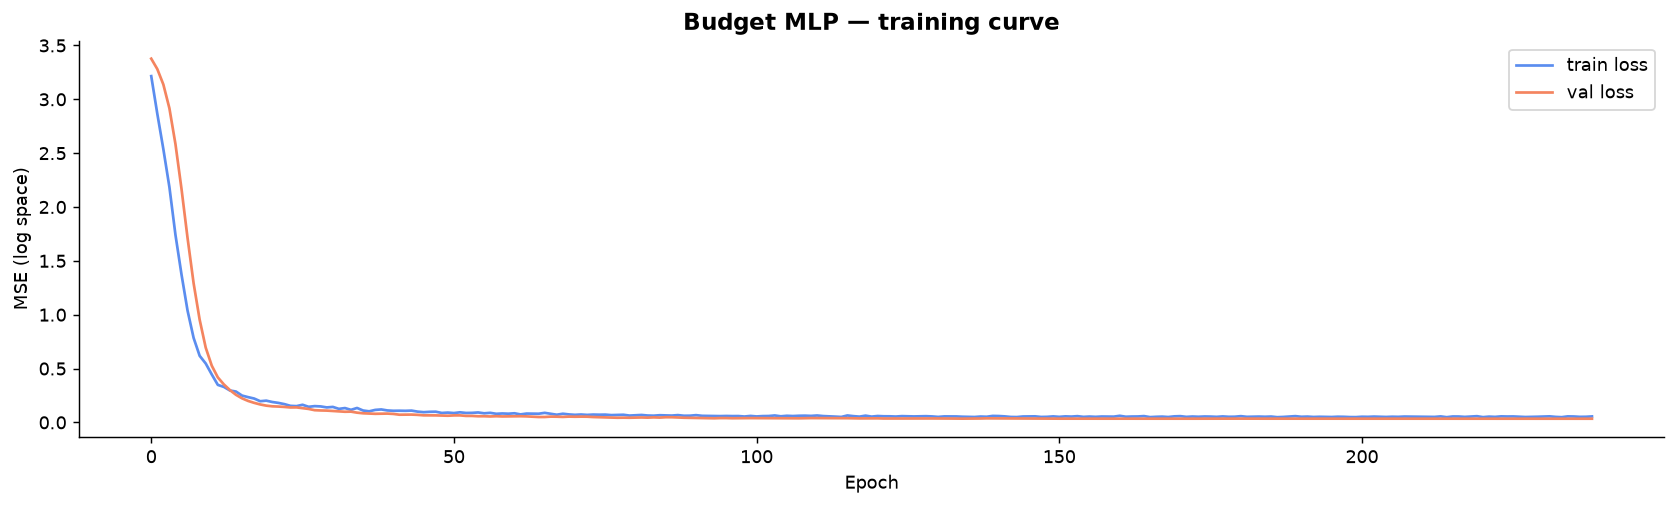

In [97]:
# Training curves — loss over epochs, useful for spotting over/underfitting
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
for ax, res, title in [
    (axes, dl_budget,   'Budget MLP — training curve'),
]:
    h = res['history'].history
    ax.plot(h['loss'], label='train loss', color=ACCENT)
    ax.plot(h['val_loss'], label='val loss', color=ACCENT2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log space)')
    ax.legend()
plt.tight_layout(); plt.show()


=== Worst 15 predictions (highest % error) ===
                                project_id  actual   predicted  abs_error  pct_error
2716  9d194fc6-84a1-4ff5-9f57-0e694e26e6b2    0.68   50.150002      49.47    7302.15
658   232ca616-0e3b-4d8e-9446-7f459f446133    0.55   39.970001      39.42    7154.92
5970  748332b8-d333-479a-ad27-84502562a015    9.65  549.520020     539.87    5592.34
2099  8a5033f0-d536-4ffd-8577-054e82361dbe    0.98   46.869999      45.90    4703.40
2702  89cc0e42-2cef-4b1a-a7ca-87f781b92292    1.30   48.110001      46.81    3607.33
3423  c50981db-5fbe-442b-b43d-ff7384035085    1.73   57.380001      55.66    3219.24
477   834ba26c-6160-4df9-a959-4d7382c7ee11    0.63   17.660000      17.03    2700.40
4398  1ffc56ff-a4e8-4d62-a960-18b14a380e4a    1.81   49.830002      48.02    2645.80
4002  4b3e618f-2315-4f27-9c0a-408e72ad80d5    1.93   52.680000      50.74    2625.97
2691  958f3824-8611-4655-87a2-2414c8691f5e    1.21   33.080002      31.87    2625.61
2695  84838520-b31

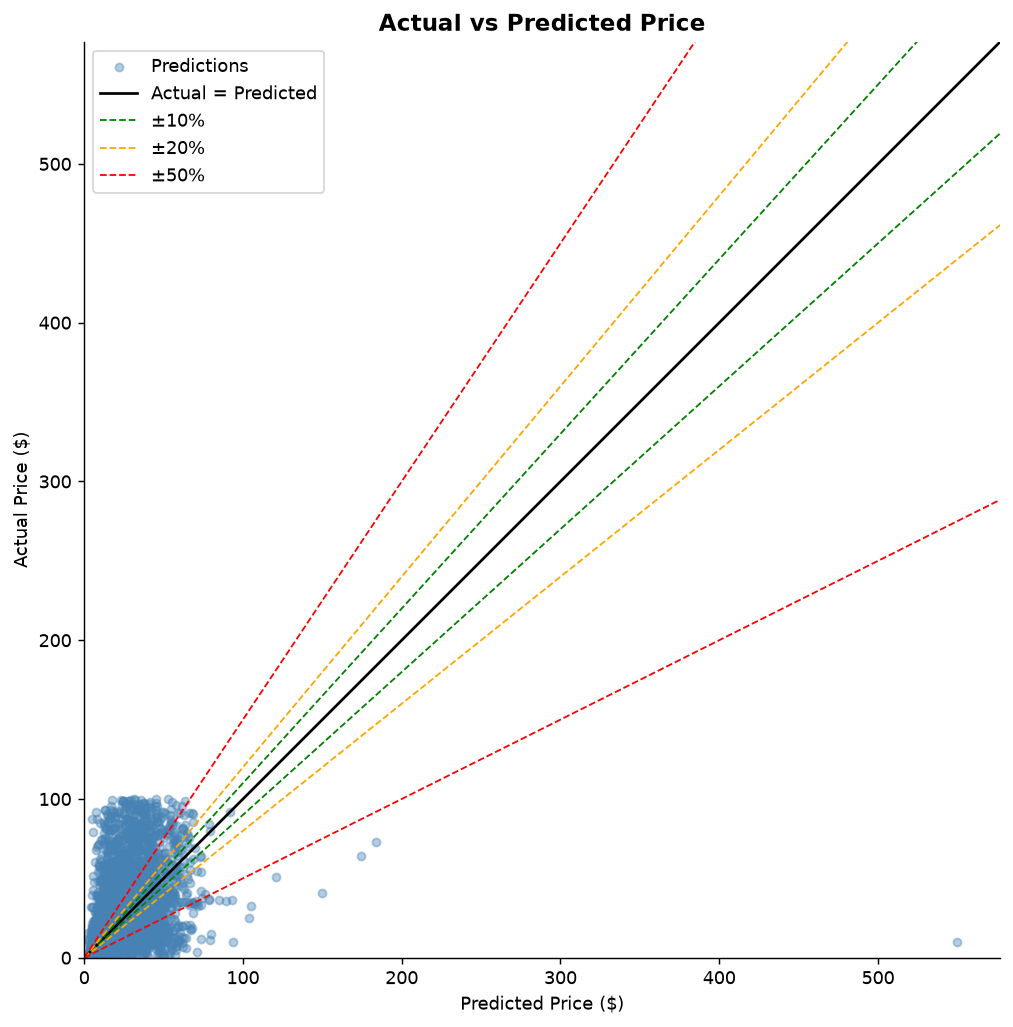

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Actual vs Predicted comparison table
# ============================================================

actual_usd    = np.expm1(yB_te)
predicted_usd = np.expm1(dl_budget['pred_test'])

comparison = pd.DataFrame({
    'project_id': df.loc[X_te.index, 'project_id'].values,   # adjust `df` to whatever your source frame is named
    'actual': actual_usd,
    'predicted': predicted_usd,
}, index=X_te.index)

comparison['abs_error']   = (comparison['actual'] - comparison['predicted']).abs()
comparison['pct_error']   = comparison['abs_error'] / comparison['actual'] * 100

comparison_sorted_worst = comparison.sort_values('pct_error', ascending=False)
comparison_sorted_best  = comparison.sort_values('pct_error', ascending=True)

print("=== Worst 15 predictions (highest % error) ===")
print(comparison_sorted_worst.head(15).round(2).to_string())

print()
print("=== Best 15 predictions (lowest % error) ===")
print(comparison_sorted_best.head(15).round(2).to_string())

print()
print(f"Median % error : {comparison['pct_error'].median():.2f}%")
print(f"Mean % error   : {comparison['pct_error'].mean():.2f}%")

# ============================================================
# Actual vs Predicted scatter chart with error-band lines
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(comparison['predicted'], comparison['actual'],
           alpha=0.4, s=20, color='steelblue', label='Predictions')

lims = [0, max(comparison['actual'].max(), comparison['predicted'].max()) * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

# actual = predicted (perfect prediction line)
ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')

# tolerance bands: actual within ±p% of predicted
for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
    ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
             label=f'±{int(pct*100)}%')
    ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Predicted Price ($)')
ax.set_ylabel('Actual Price ($)')
ax.set_title('Actual vs Predicted Price')
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Dropped 814 rows (21.4%) above $50


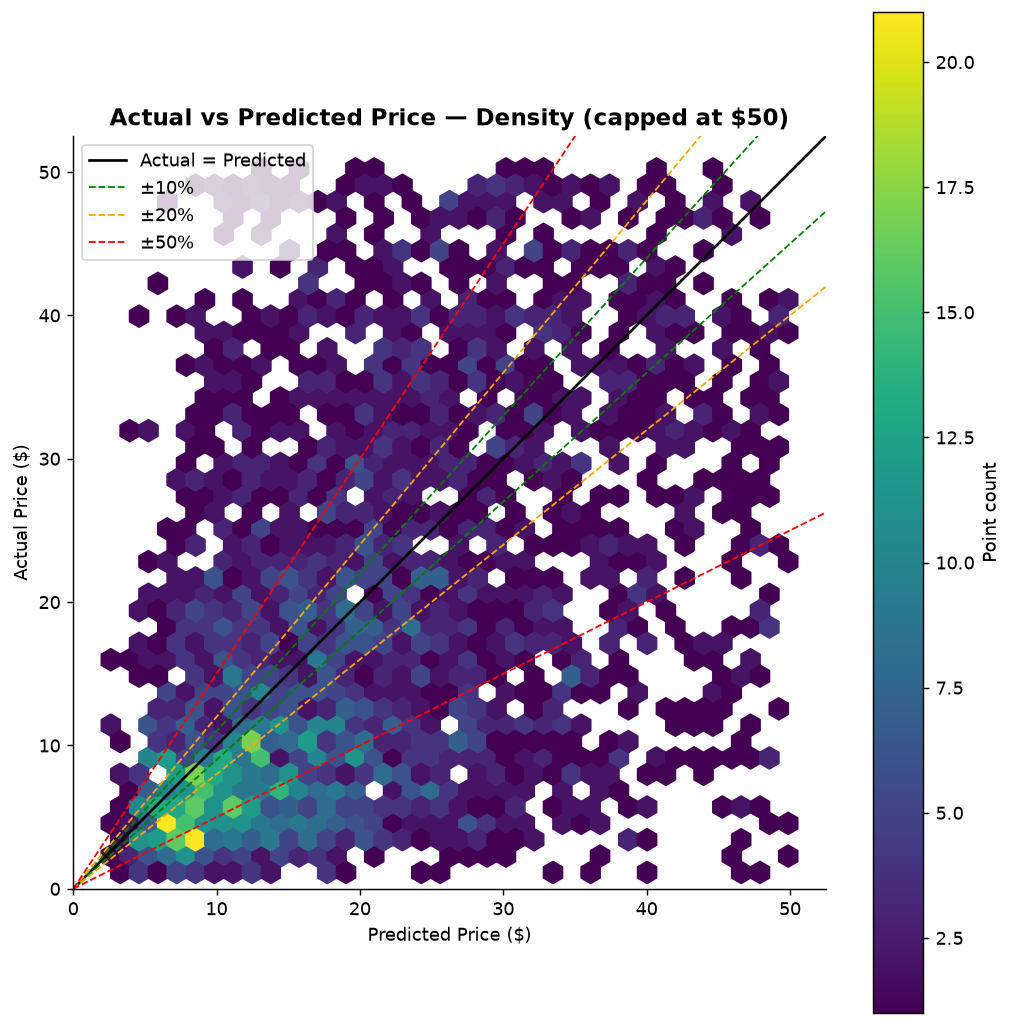

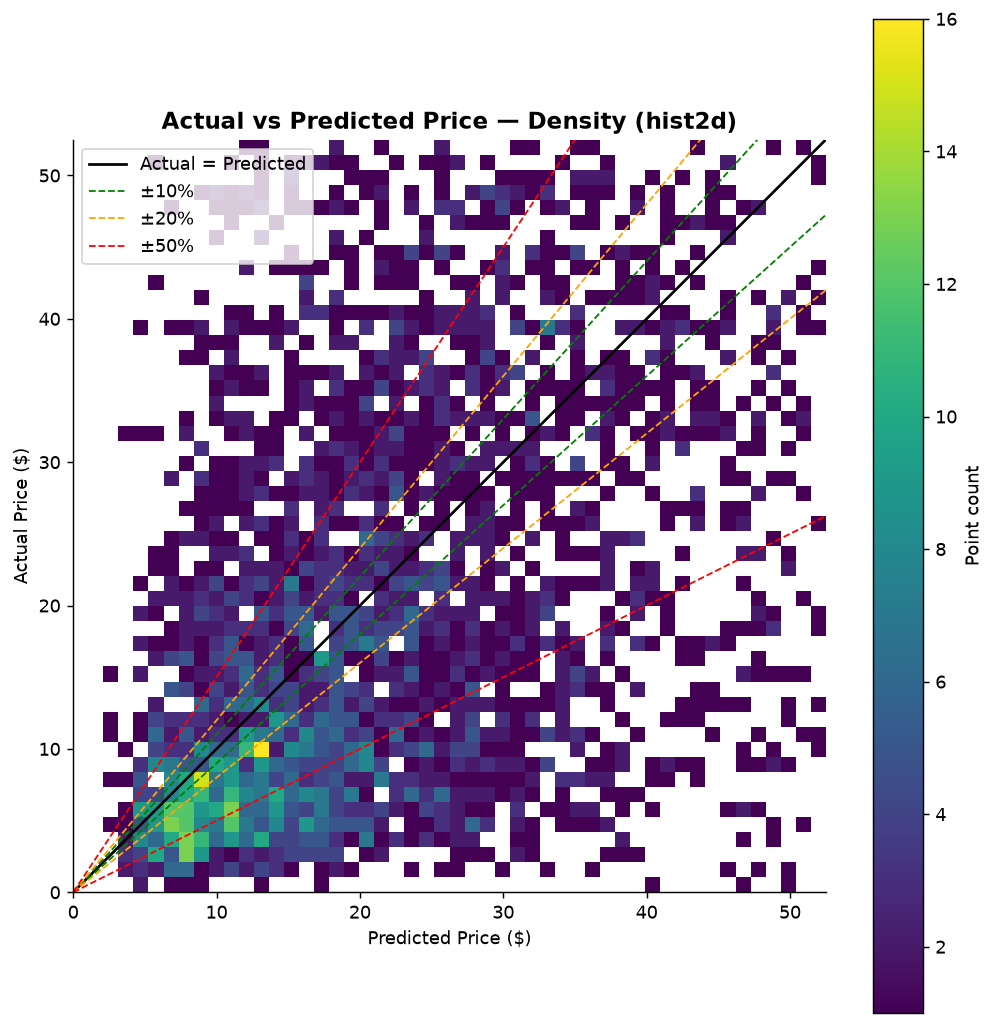

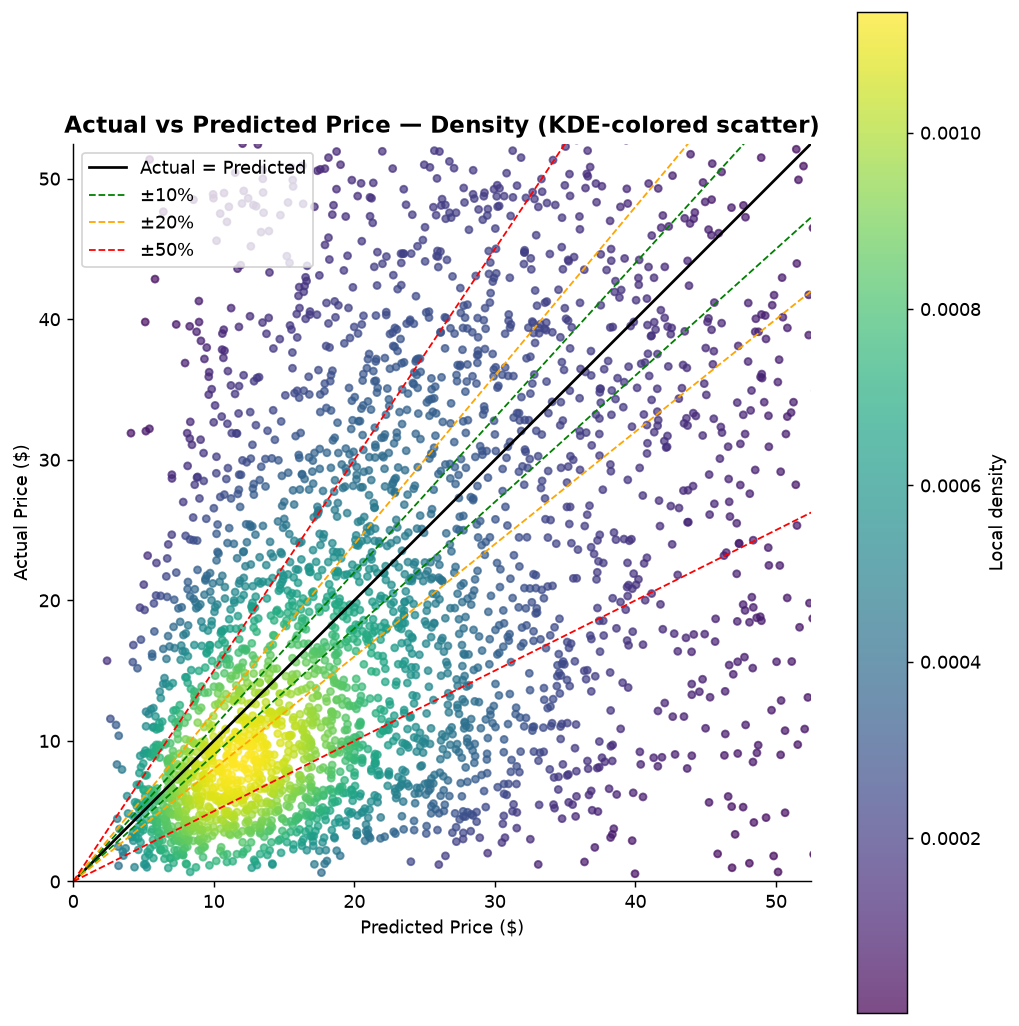

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

# ============================================================
# Set your cap here
# ============================================================
MAX_PRICE = 50   # adjust this — try comparison['actual'].quantile(0.95) to auto-pick a reasonable cutoff

plot_data = comparison[
    (comparison['actual'] <= MAX_PRICE) &
    (comparison['predicted'] <= MAX_PRICE)
]

n_dropped = len(comparison) - len(plot_data)
print(f"Dropped {n_dropped} rows ({n_dropped/len(comparison):.1%}) above ${MAX_PRICE:,}")

lims = [0, MAX_PRICE * 1.05]
x_line = np.linspace(lims[0], lims[1], 200)

def draw_bands(ax):
    ax.plot(x_line, x_line, color='black', linewidth=1.5, label='Actual = Predicted')
    for pct, color in [(0.10, 'green'), (0.20, 'orange'), (0.50, 'red')]:
        ax.plot(x_line, x_line * (1 + pct), color=color, linestyle='--', linewidth=1,
                 label=f'±{int(pct*100)}%')
        ax.plot(x_line, x_line * (1 - pct), color=color, linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Actual Price ($)')
    ax.set_aspect('equal', adjustable='box')

# ------------------------------------------------------------
# hexbin, capped
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(plot_data['predicted'], plot_data['actual'],
                gridsize=40, cmap='viridis', mincnt=1, extent=[*lims, *lims])
draw_bands(ax)
ax.set_title(f'Actual vs Predicted Price — Density (capped at ${MAX_PRICE:,})')
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Point count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
h = ax.hist2d(comparison['predicted'], comparison['actual'],
              bins=50, cmap='viridis', cmin=1, range=[lims, lims])
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (hist2d)')
ax.legend(loc='upper left')
fig.colorbar(h[3], ax=ax, label='Point count')
plt.tight_layout()
plt.show()


xy = np.vstack([comparison['predicted'], comparison['actual']])
density = gaussian_kde(xy)(xy)
order = density.argsort()  # plot densest points last so they're on top

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(comparison['predicted'].values[order], comparison['actual'].values[order],
                 c=density[order], cmap='viridis', s=15, alpha=0.7)
draw_bands(ax)
ax.set_title('Actual vs Predicted Price — Density (KDE-colored scatter)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='Local density')
plt.tight_layout()
plt.show()


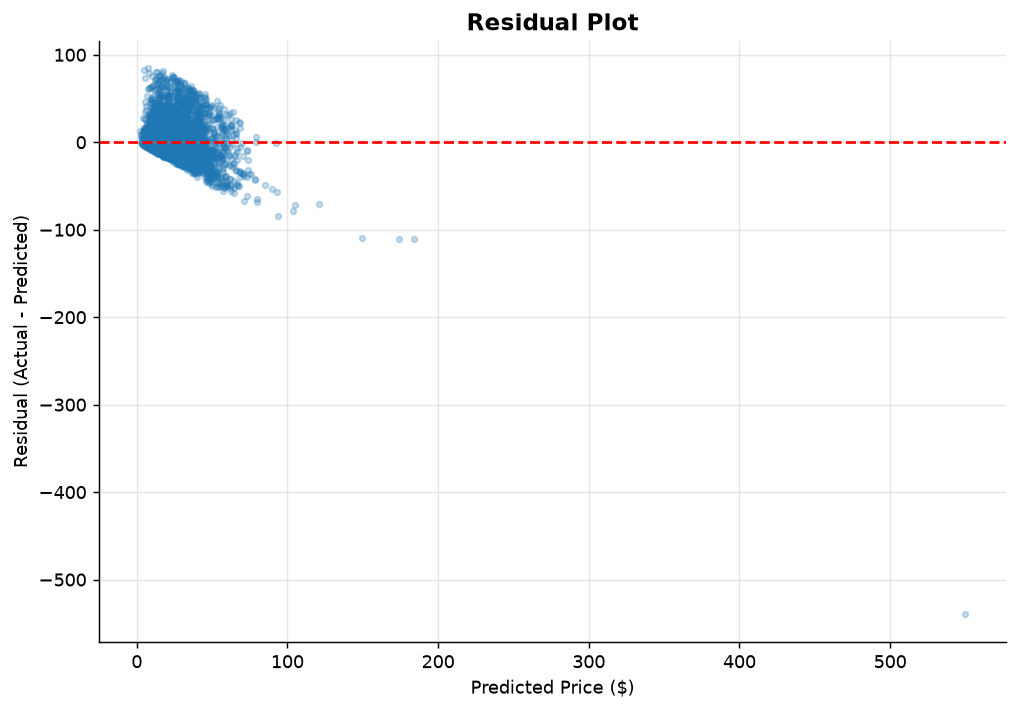

In [13]:
actual = comparison['actual']
pred = comparison['predicted']
residual = actual - pred

plt.figure(figsize=(9,6))

plt.scatter(
    pred,
    residual,
    alpha=.25,
    s=10
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.grid(alpha=.3)
plt.show()

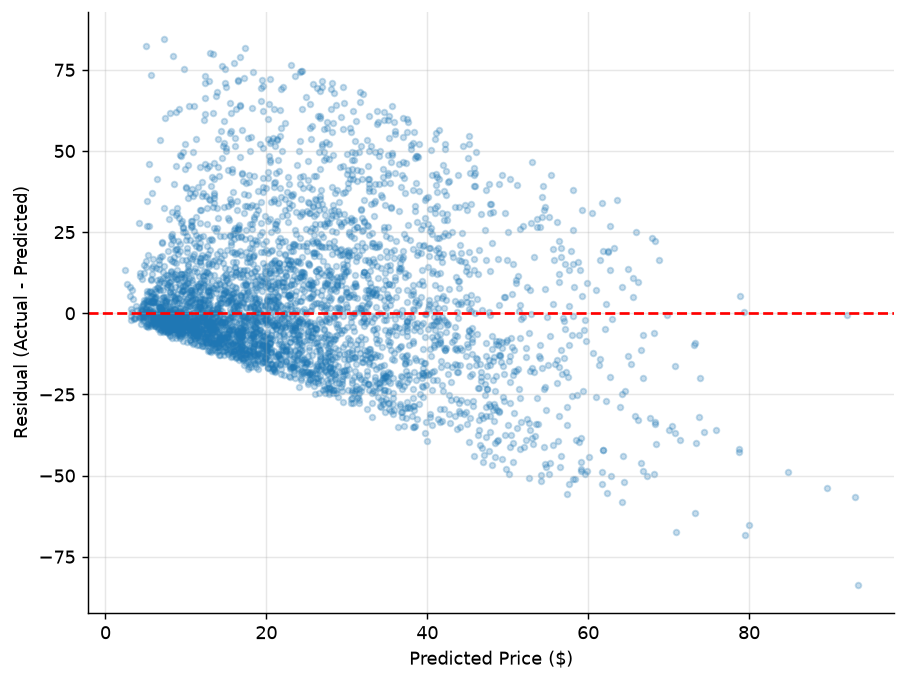

: 

In [ ]:
mask = (
    (pred < 100) &
    (residual > -100) &
    (residual < 100)
)

plt.figure(figsize=(8,6))

plt.scatter(
    pred[mask],
    residual[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.show()

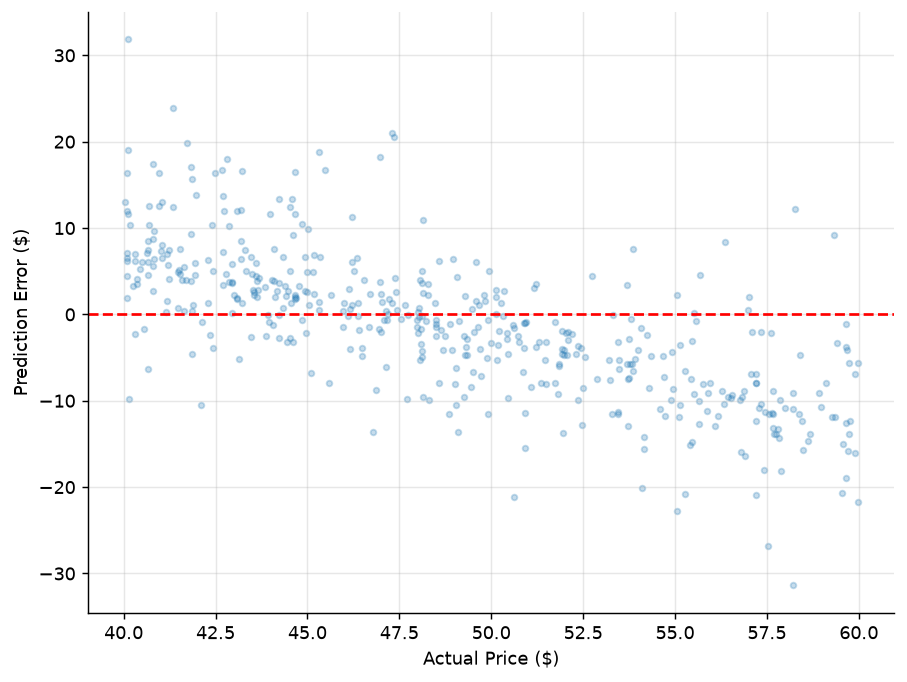

In [88]:
error = pred - actual

mask = (
    (actual < 1000) &
    (error > -1000) &
    (error < 1000)
)

plt.figure(figsize=(8,6))

plt.scatter(
    actual[mask],
    error[mask],
    alpha=0.25,
    s=10
)

plt.axhline(0, color="red", ls="--")

plt.xlabel("Actual Price ($)")
plt.ylabel("Prediction Error ($)")
plt.grid(alpha=0.3)

plt.show()

In [49]:
pred = np.expm1(pred_tr)
actual = np.expm1(yB_tr)

# print(pred.head , actual.shape)

print(np.expm1(yB_tr))

19381    53.907145
13400    20.398380
15786     3.623812
7570     29.483138
3862      3.021563
           ...    
18730    10.027375
8121     10.578233
8571     32.222550
927      34.931011
12829    81.117255
Name: log_target_budget, Length: 8883, dtype: float64


In [13]:
bins = [0,10,20,30,40,50,75,100,np.inf]

df2 = pd.DataFrame({
    "actual": actual,
    "pred": pred,
})

df2["bin"] = pd.cut(df2["actual"], bins)

summary = df2.groupby("bin").agg(
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)

# MAE
summary["mae"] = df2.groupby("bin").apply(
    lambda g: np.mean(np.abs(g["actual"] - g["pred"]))
)

# Mean Absolute Percentage Error (MAPE)
summary["mape"] = df2.groupby("bin").apply(
    lambda g: np.mean(
        np.abs(g["actual"] - g["pred"])
        / g["actual"].clip(lower=1)
    ) * 100
)

# Bias (positive = overpredict, negative = underpredict)
summary["bias"] = summary["mean_pred"] - summary["mean_actual"]

print(summary.round(2))

NameError: name 'actual' is not defined

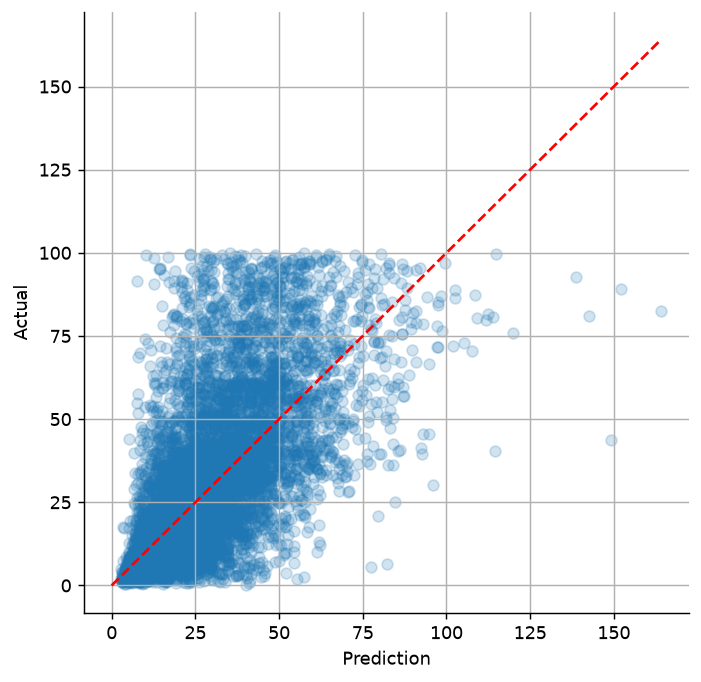

In [51]:
plt.figure(figsize=(6,6))

plt.scatter(
    np.expm1(pred_tr),
    np.expm1(yB_tr),
    alpha=0.2,
)

m = max(
    np.expm1(pred_tr).max(),
    np.expm1(yB_tr).max()
)

plt.plot([0,m],[0,m],'r--')

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.grid(True)

In [12]:
bins = [0,10,20,30,40,50,75,100]

counts = pd.cut(df["actual"], bins).value_counts().sort_index()

print(counts)

KeyError: 'actual'

In [28]:
PCT_THRESHOLD = 0.20   # e.g. 20% below budget_min

threshold = df_raw['budget_min'] * (1 - PCT_THRESHOLD)
count = (df_raw['final_budget'] < threshold).sum()

print(f"Rows where final_budget < {PCT_THRESHOLD:.0%} below budget_min: "
      f"{count} ({count/len(df_raw):.2%} of {len(df_raw)} rows)")

Rows where final_budget < 20% below budget_min: 662 (3.37% of 19668 rows)


Clipped 2 rows (0.1%) beyond ±$100


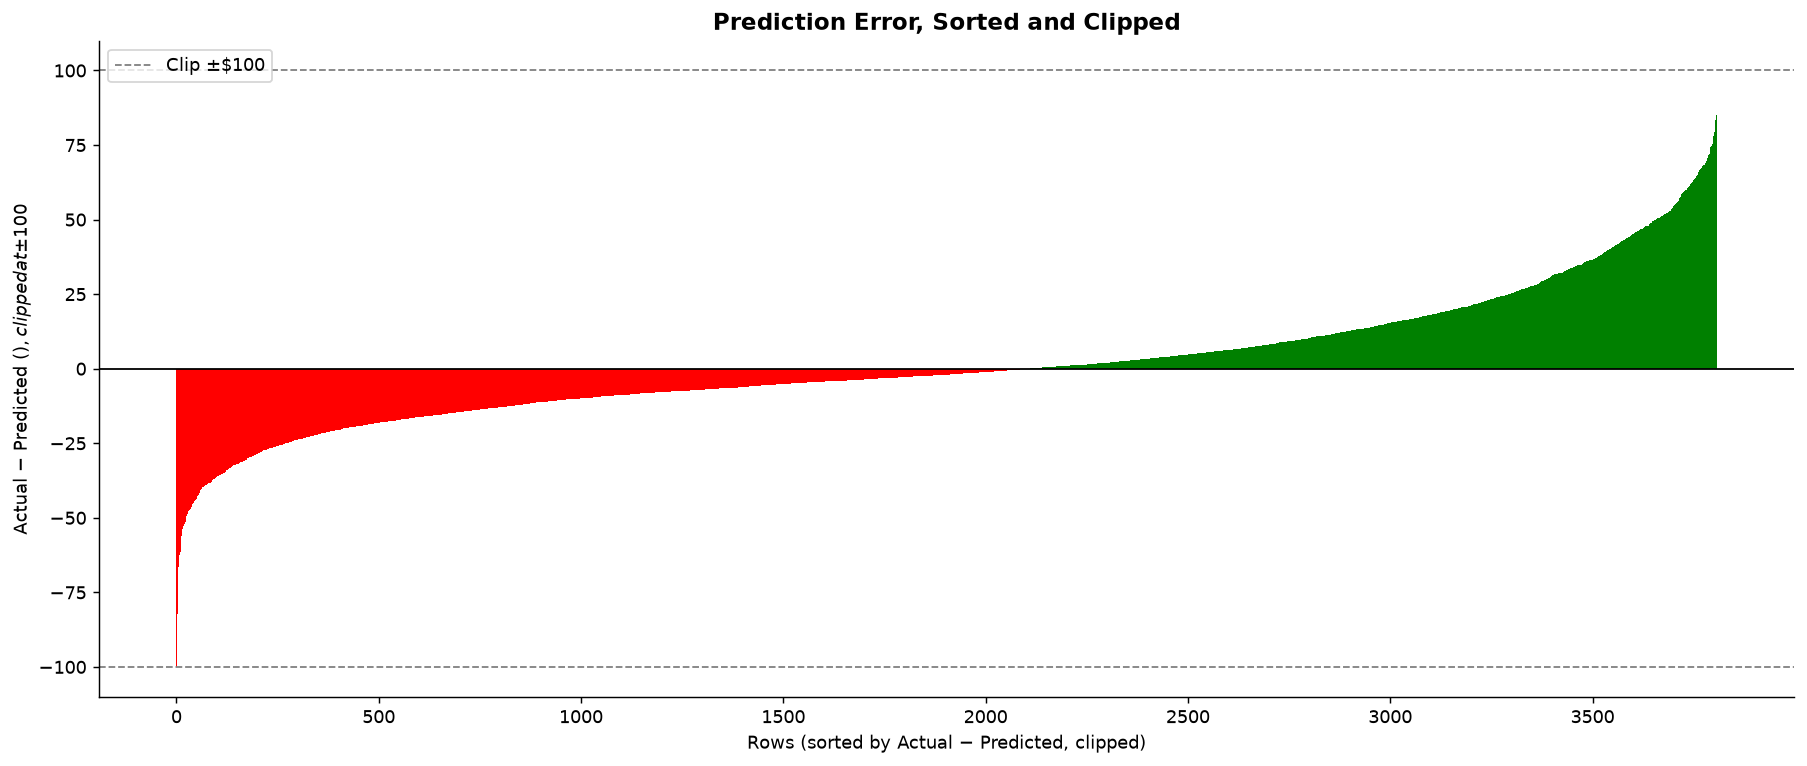

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Set your cap here — errors beyond this get clipped to the cap
# ============================================================
MAX_DIFF = 100   # adjust — try comparison['diff'].abs().quantile(0.95) to auto-pick

comparison['diff'] = comparison['actual'] - comparison['predicted']

# clip, don't drop — keeps every row, just caps the extreme values visually
comparison['diff_clipped'] = comparison['diff'].clip(-MAX_DIFF, MAX_DIFF)

n_clipped = (comparison['diff'].abs() > MAX_DIFF).sum()
print(f"Clipped {n_clipped} rows ({n_clipped/len(comparison):.1%}) beyond ±${MAX_DIFF:,}")

sorted_by_diff = comparison.sort_values('diff_clipped').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red' if d < 0 else 'green' for d in sorted_by_diff['diff_clipped']]
ax.bar(sorted_by_diff.index, sorted_by_diff['diff_clipped'], color=colors, width=1.0)

# mark the clip boundaries so it's clear where clipping kicks in
ax.axhline(MAX_DIFF, color='gray', linestyle='--', linewidth=1, label=f'Clip ±${MAX_DIFF:,}')
ax.axhline(-MAX_DIFF, color='gray', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel('Rows (sorted by Actual − Predicted, clipped)')
ax.set_ylabel(f'Actual − Predicted ($), clipped at ±${MAX_DIFF:,}')
ax.set_title('Prediction Error, Sorted and Clipped')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 6 · Model comparison & residual plots (classical models)

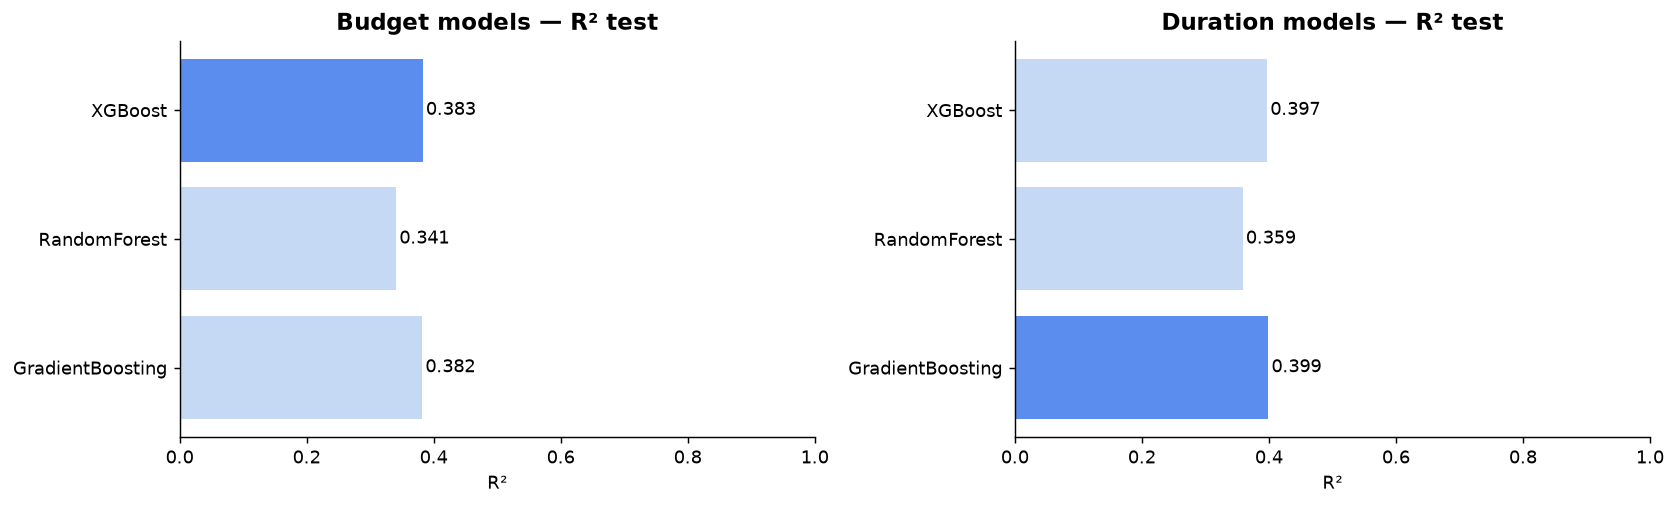

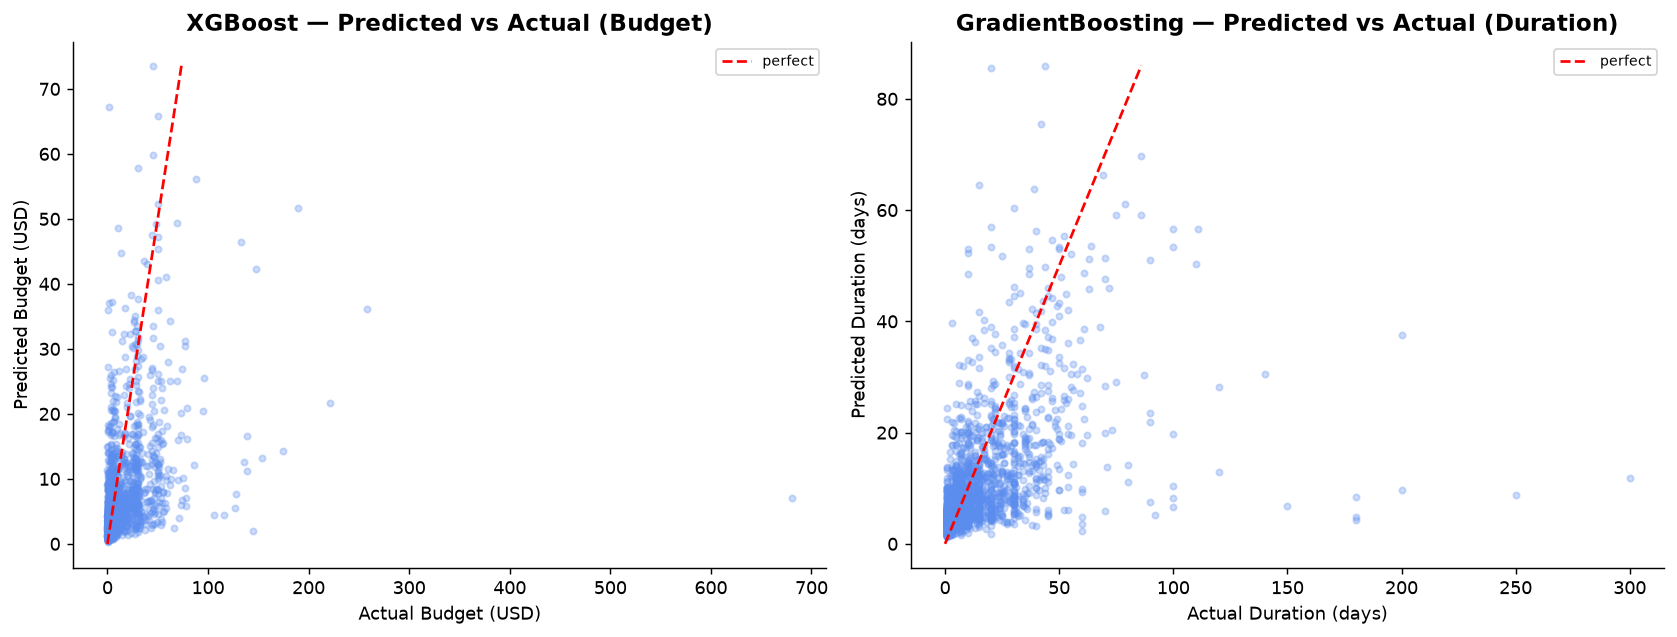

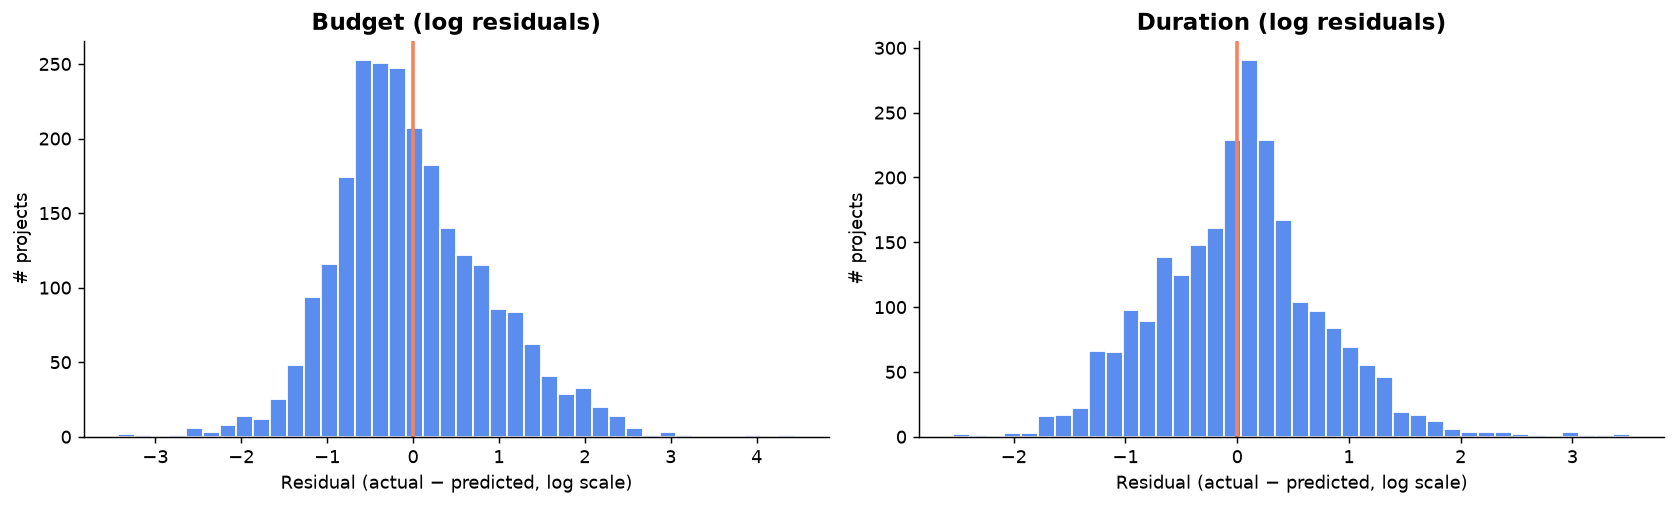

In [ ]:
# Side-by-side R² comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, results, title in [
    (axes[0], budget_results,   'Budget models — R² test'),
    (axes[1], duration_results, 'Duration models — R² test'),
]:
    names  = list(results.keys())
    r2s    = [results[n]['r2_test'] for n in names]
    colors = [ACCENT if r == max(r2s) else '#c5d9f5' for r in r2s]
    ax.barh(names, r2s, color=colors)
    for i, v in enumerate(r2s):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

# Predicted vs actual for best budget model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, label, unit in [
    (axes[0], best_budget,   'Budget', 'USD'),
    (axes[1], best_duration, 'Duration', 'days'),
]:
    y_true = np.expm1(yB_te if label=='Budget' else yD_te)
    y_pred = np.expm1(res['pred_test'])
    scale  = 1 if label == 'Budget' else 1  # already in USD, no scaling needed
    ax.scatter(y_true/scale, y_pred/scale, alpha=0.3, s=12, color=ACCENT)
    lim = max(y_true.quantile(0.97), y_pred.max()) / scale
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f'Actual {label} ({unit})')
    ax.set_ylabel(f'Predicted {label} ({unit})')
    ax.set_title(f'{res["name"]} — Predicted vs Actual ({label})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Residuals distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, y_te, label in [
    (axes[0], best_budget,   yB_te, 'Budget (log residuals)'),
    (axes[1], best_duration, yD_te, 'Duration (log residuals)'),
]:
    residuals = np.array(y_te) - res['pred_test']
    ax.hist(residuals, bins=40, color=ACCENT, edgecolor='white')
    ax.axvline(0, color=ACCENT2, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('Residual (actual − predicted, log scale)')
    ax.set_ylabel('# projects')
plt.tight_layout(); plt.show()

## 6b · Classical vs Deep Learning comparison
How does the best tree-based model stack up against the neural net?

  Target              Model  R2_test  MAE_test
  Budget            XGBoost 0.382694  7.854053
  Budget DeepLearning (MLP) 0.303992  8.116897
Duration   GradientBoosting 0.398919  7.755881
Duration DeepLearning (MLP) 0.328920  8.405992


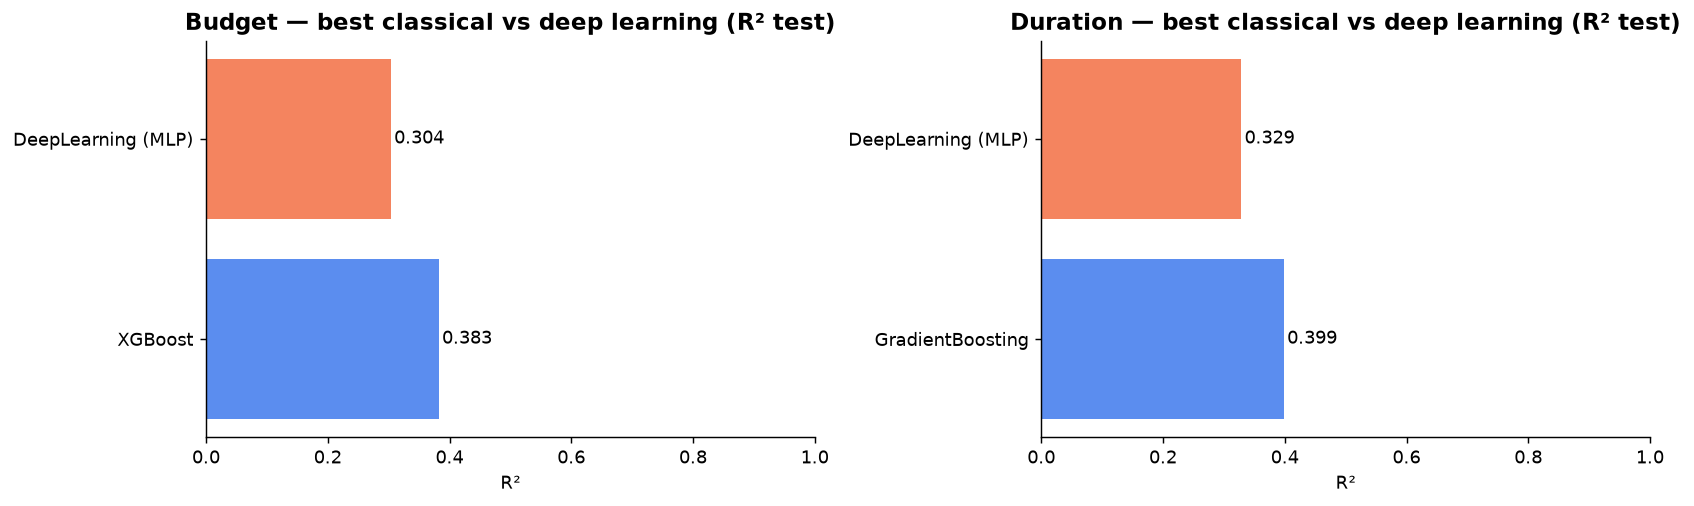


Budget: classical tree model wins on this dataset (classical R²=0.383 vs DL R²=0.304)
Duration: classical tree model wins on this dataset (classical R²=0.399 vs DL R²=0.329)

Note: tree ensembles (GBM/RF/XGBoost) often out-perform small MLPs on tabular
data like this, especially with a few thousand rows and mostly categorical /
count features — deep learning tends to need much more data (or embeddings for
high-cardinality categoricals) to pull ahead here.


In [ ]:
comparison_rows = [
    ('Budget',   best_budget_name,       best_budget['r2_test'],   best_budget['mae_test']),
    ('Budget',   'DeepLearning (MLP)',   dl_budget['r2_test'],     dl_budget['mae_test']),
    ('Duration', best_duration_name,     best_duration['r2_test'], best_duration['mae_test']),
    ('Duration', 'DeepLearning (MLP)',   dl_duration['r2_test'],   dl_duration['mae_test']),
]
comparison_df = pd.DataFrame(comparison_rows, columns=['Target', 'Model', 'R2_test', 'MAE_test'])
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, ['Budget', 'Duration']):
    sub = comparison_df[comparison_df['Target'] == target]
    colors = [ACCENT if 'Deep' not in m else ACCENT2 for m in sub['Model']]
    ax.barh(sub['Model'], sub['R2_test'], color=colors)
    for i, (v, m) in enumerate(zip(sub['R2_test'], sub['Model'])):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_title(f'{target} — best classical vs deep learning (R² test)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('R²')
plt.tight_layout(); plt.show()

print()
for target, classical_r2, dl_r2 in [
    ('Budget',   best_budget['r2_test'],   dl_budget['r2_test']),
    ('Duration', best_duration['r2_test'], dl_duration['r2_test']),
]:
    winner = 'classical tree model' if classical_r2 >= dl_r2 else 'deep learning'
    print(f'{target}: {winner} wins on this dataset (classical R²={classical_r2:.3f} vs DL R²={dl_r2:.3f})')
print('\nNote: tree ensembles (GBM/RF/XGBoost) often out-perform small MLPs on tabular')
print('data like this, especially with a few thousand rows and mostly categorical /')
print('count features — deep learning tends to need much more data (or embeddings for')
print('high-cardinality categoricals) to pull ahead here.')


## 7 · Feature importance (global)

In [14]:
TOP_N = 25

def plot_importance(model, feature_names, title, top_n=TOP_N):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        return
    imp = imp.nlargest(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp[::-1].plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout(); plt.show()
    return imp

print('=== Budget model feature importance ===')
imp_b = plot_importance(best_budget['model'], ALL_FEATURES, f'Top {TOP_N} Features — Budget ({best_budget_name})')
print(imp_b.head(10).to_string())

print('\n=== Duration model feature importance ===')
imp_d = plot_importance(best_duration['model'], ALL_FEATURES, f'Top {TOP_N} Features — Duration ({best_duration_name})')
print(imp_d.head(10).to_string())

=== Budget model feature importance ===


NameError: name 'best_budget' is not defined

## 8 · SHAP — per-prediction explanations
SHAP shows **why** the model made each prediction, not just which features matter on average.

Computing SHAP values for budget model...


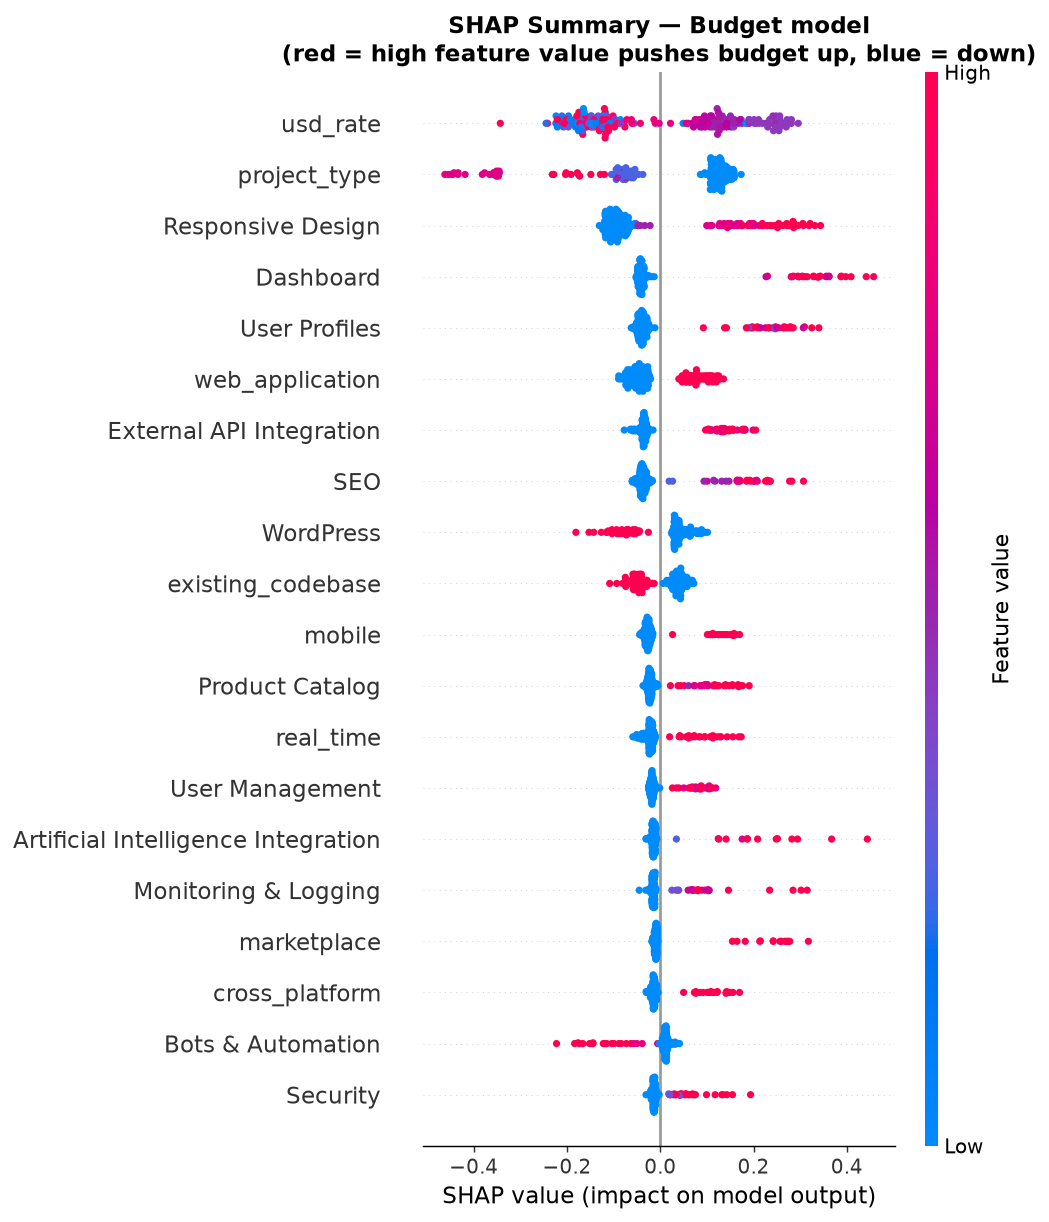

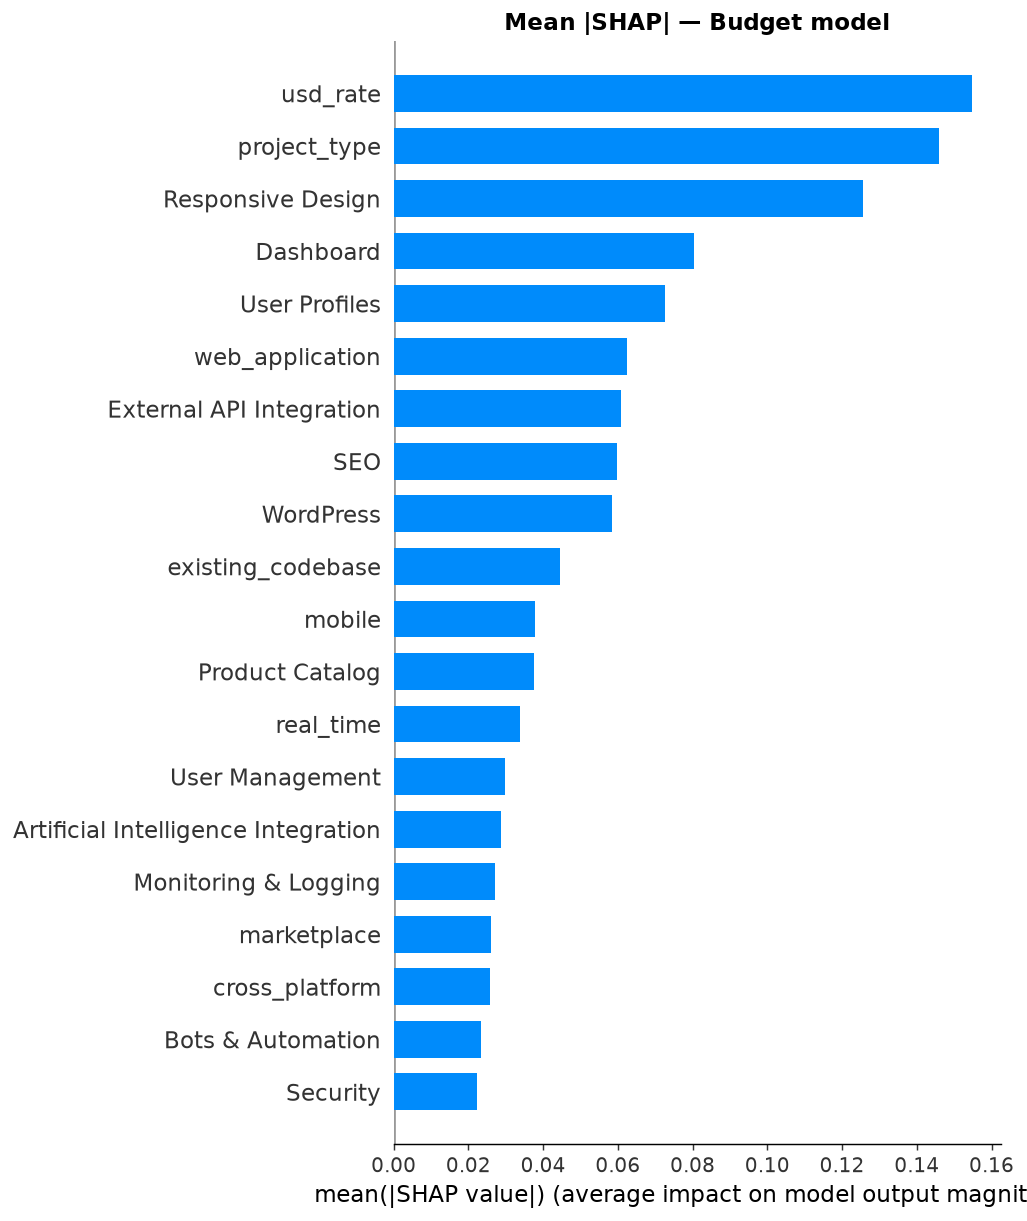


Explaining prediction for sample index 146 (predicted budget: 66)


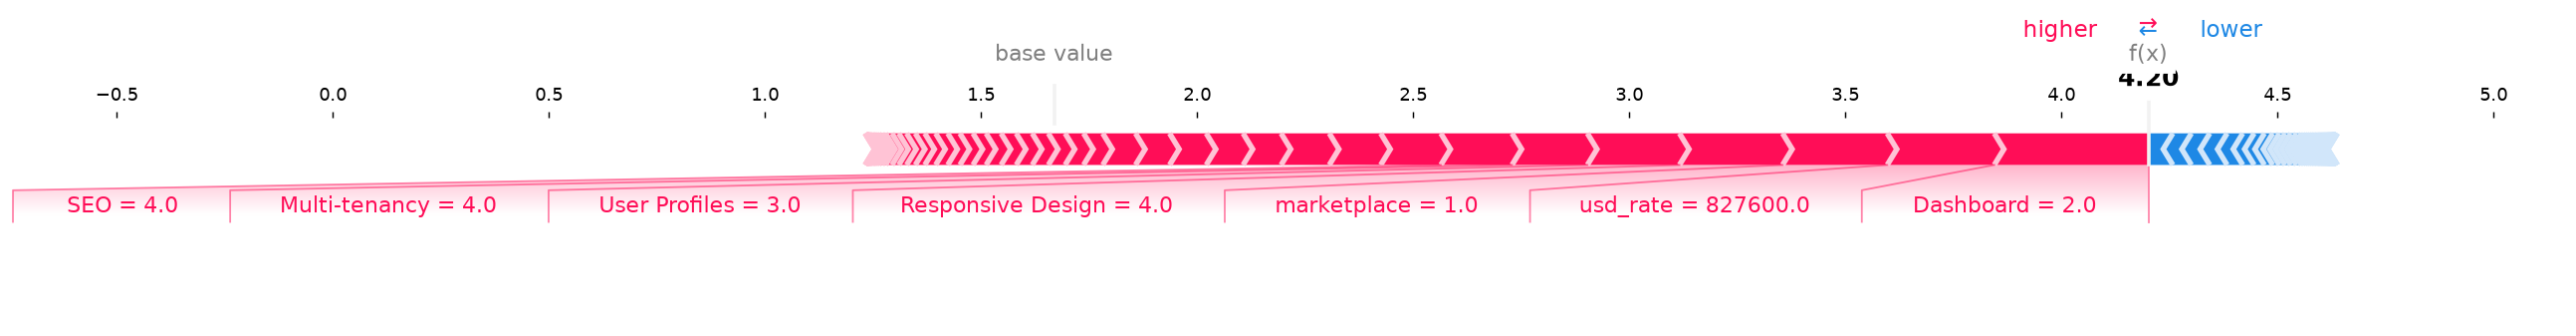

In [ ]:
# Use a subsample for speed (SHAP is O(n * features) per call)
SHAP_SAMPLE = min(200, len(X_te))
X_shap = X_te.sample(SHAP_SAMPLE, random_state=42)

print('Computing SHAP values for budget model...')
explainer_b = shap.TreeExplainer(best_budget['model'])
shap_vals_b = explainer_b.shap_values(X_shap)

# Summary plot — global view: which features drive predictions most?
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.title('SHAP Summary — Budget model\n(red = high feature value pushes budget up, blue = down)')
plt.tight_layout(); plt.show()

# Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_vals_b, X_shap, feature_names=ALL_FEATURES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| — Budget model')
plt.tight_layout(); plt.show()

# Single prediction explanation (most expensive predicted project)
idx = np.argmax(np.expm1(best_budget['model'].predict(X_shap)))
print(f'\nExplaining prediction for sample index {idx} '
      f'(predicted budget: {np.expm1(best_budget["model"].predict(X_shap.iloc[[idx]])[0]):,.0f})')
shap.force_plot(explainer_b.expected_value, shap_vals_b[idx], X_shap.iloc[idx],
                feature_names=ALL_FEATURES, matplotlib=True, show=False)
plt.tight_layout(); plt.show()

## 9 · Error analysis
Where does the model fail? Look at the worst predictions to spot patterns.

In [ ]:
test_idx = X_te.index
error_df = df.loc[test_idx, ['title','category','target_budget',
                               'feature_count','description_word_count']].copy()
error_df['pred_budget']   = np.expm1(best_budget['pred_test'])

error_df['budget_err_pct'] = (error_df['pred_budget'] - error_df['target_budget']).abs() / error_df['target_budget'] * 100
error_df['duration_err_pct'] = (error_df['pred_duration'] - error_df['target_duration']).abs() / error_df['target_duration'] * 100

# Error % distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in [
    (axes[0], 'budget_err_pct',   'Budget absolute error %'),
    (axes[1], 'duration_err_pct', 'Duration absolute error %'),
]:
    data = error_df[col].clip(upper=error_df[col].quantile(0.95))
    ax.hist(data, bins=30, color=ACCENT, edgecolor='white')
    ax.axvline(data.median(), color=ACCENT2, linewidth=2, label=f'median={data.median():.0f}%')
    ax.set_title(label)
    ax.set_xlabel('% error')
    ax.set_ylabel('# projects')
    ax.legend()
plt.tight_layout(); plt.show()

# Worst predictions
print('=== 10 worst budget predictions ===')
worst = error_df.nlargest(10, 'budget_err_pct')[[
    'title','category','target_budget','pred_budget','budget_err_pct','feature_count','description_word_count'
]]
worst['target_budget'] = worst['target_budget'].map(lambda x: f'${x:,.0f}')
worst['pred_budget']   = worst['pred_budget'].map(lambda x: f'${x:,.0f}')
worst['budget_err_pct'] = worst['budget_err_pct'].map(lambda x: f'{x:.0f}%')
print(worst.to_string(index=False))

# Error vs feature count scatter
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(error_df['feature_count'], error_df['budget_err_pct'].clip(upper=500),
           alpha=0.3, s=12, color=ACCENT)
ax.set_xlabel('Number of features tagged')
ax.set_ylabel('Budget error %')
ax.set_title('Does more features → lower error?')
plt.tight_layout(); plt.show()

ValueError: Length of values (3371) does not match length of index (5056)

## 10 · Cross-validation (more reliable than a single split)

In [ ]:
print('5-fold CV R² (budget) — this takes ~30s...')
cv_scores = cross_val_score(best_budget['model'], X, yB, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_budget_name}: {cv_scores.round(3)}  mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print('\n5-fold CV R² (duration)...')
cv_scores_d = cross_val_score(best_duration['model'], X, yD, cv=5, scoring='r2', n_jobs=-1)
print(f'  {best_duration_name}: {cv_scores_d.round(3)}  mean={cv_scores_d.mean():.3f} ± {cv_scores_d.std():.3f}')

5-fold CV R² (budget) — this takes ~30s...
  XGBoost: [-0.206  0.117  0.282  0.164  0.292]  mean=0.130 ± 0.181

5-fold CV R² (duration)...
  GradientBoosting: [-0.009  0.33   0.36   0.253 -1.873]  mean=-0.188 ± 0.853


## 11 · Inference helper
Predict budget and duration for a new project — fill in the dict with real values.

In [ ]:
def predict_project(feature_dict: dict) -> dict:
    """
    Pass a dict with the same keys as ALL_FEATURES.
    Missing keys default to 0. Enum values should be strings (e.g. 'medium').
    Returns {'budget': float, 'duration_days': float}.
    """
    row = pd.DataFrame([{f: feature_dict.get(f, 0) for f in ALL_FEATURES}])
    row[ENUM_COLS] = enc.transform(row[ENUM_COLS].astype(str))
    budget_log   = best_budget['model'].predict(row)[0]
    duration_log = best_duration['model'].predict(row)[0]
    return {
        'budget_usd':    int(np.expm1(budget_log)),
        'duration_days': round(np.expm1(duration_log), 1),
    }

# Example: a mid-complexity web app with payment processing
example = {
    'Payment Processing': 4,
    'Authentication': 4,
    'Dashboard': 3,
    'web_application': 1,
    'ecommerce': 1,
    'business_logic': 'medium',
    'ui_complexity': 'medium',
    'integration_complexity': 'medium',
    'algorithmic_complexity': 'low',
    'project_type': 'bugfix',
    'ai_level': 'none',
    'data_volume': 'small',
    'estimated_screens': 12,
    'estimated_entities': 6,
    'external_api_count': 2,
    'description_word_count': 80,
    'feature_count': 8,
    'web': 1,
}

result = predict_project(example)
print(f"Predicted budget:   \${result['budget_usd']:>12,.0f} USD")
print(f"Predicted duration: {result['duration_days']:>12.1f} days")

KeyError: "['ai_level', 'business_logic', 'data_volume', 'integration_complexity', 'ui_complexity', 'algorithmic_complexity'] not in index"